
# Corrected Analysis of Intrinsic Dimension in Jet-Flow PIV Data

## 1. Motivation

In experimental fluid mechanics, particularly in turbulent jet studies, the data acquired by Particle Image Velocimetry (PIV) are high-dimensional. A single snapshot containing the two fluctuating velocity components $(u,v)$ on a spatial grid with $N_xN_y$ points is represented as

$$
\mathbf{x}_i \in \mathbb{R}^{p}, \qquad p = 2N_xN_y.
$$

The aim of intrinsic dimension estimation is to test whether these high-dimensional observations are concentrated near a lower-dimensional set,

$$
\mathbf{x}_i \in \mathcal{M} \subset \mathbb{R}^{p}, \qquad \dim(\mathcal{M}) = d \ll p.
$$

This corrected notebook keeps the original notebook unchanged and fixes the implementation issues detected in the first exploratory version. In particular:

1. The Levina--Bickel MLE estimator is now called with the neighborhood size passed through `fit(..., n_neighbors=k)`, which is the argument used by `scikit-dimension` for the default neighborhood-based estimator.
2. DANCo is treated as a diagnostic estimator with an explicit maximum searched dimension. If the estimate reaches this maximum, it is flagged as a boundary failure rather than interpreted as a valid dimension.
3. The custom CA-PCA routine is treated as exploratory and includes boundary diagnostics. It should not be used as a thesis estimate unless it returns an interior, stable value.
4. Local PCA neighborhoods explicitly remove the query point itself.
5. Stale outputs from the original notebook are cleared so that all numerical conclusions come only from executing this corrected version.

## 2. Objectives

The notebook computes a set of global and local intrinsic-dimension diagnostics for RUN 2. The thesis-ready estimates should be based only on methods that pass their internal checks: stability with respect to neighborhood size for neighborhood-based methods, and absence of boundary saturation for methods with an explicit search range.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from tqdm import tqdm
from skdim.id import TwoNN, MLE, MiND_ML, DANCo, lPCA


# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 4. Data Preparation

We load the compressed PIV data for **RUN 2** ($St_{act} = 0.30$). The compressed files contain the **fluctuating** velocity components $u = U - \overline{U}$ and $v = V - \overline{V}$, where the time-averaged mean flow has already been subtracted during pre-processing. This is the correct input for intrinsic dimension estimation: the mean flow is a fixed point (constant across snapshots) and would not contribute to the manifold structure.

The function `make_matrix` flattens the spatial grid $(N_x \times N_y)$ into a feature vector of dimension $p = 2 N_x N_y$ (after subsampling).

**Note on normalization:** We intentionally **do not** apply Z-score normalization (e.g., `StandardScaler`). In PIV data, the velocity components carry physical meaning: their relative magnitudes encode the actual flow physics. Standardizing would artificially equalize the variance of all features, amplifying measurement noise in directions that are physically less important. The estimators employed here (TwoNN, MLE, DanCo, lPCA) operate on Euclidean distances, which are geometrically meaningful in the original, unscaled measurement space.

In [2]:
def make_matrix(U, V, subsample=None, mask=None):
    """
    Converts PIV snapshots (U, V arrays) into a feature matrix X.
    
    Parameters:
    -----------
    U, V : np.ndarray
        Shape (n_snapshots, Ny, Nx). Velocity components.
    subsample : tuple (sy, sx), optional
        Subsampling factor for the spatial grid to reduce dimensionality p.
    mask : np.ndarray, optional
        Boolean mask (Ny, Nx) where True indicates valid spatial points.

    Returns:
    --------
    X : np.ndarray
        Shape (n_snapshots, n_features). The data matrix.
    """
    n_snap, Ny, Nx = U.shape
    
    # 1. Identify valid pixels (non-NaN and mask)
    valid_pixels = np.isfinite(U).all(axis=0) & np.isfinite(V).all(axis=0)
    if mask is not None:
        valid_pixels &= mask
        
    # 2. Subsample grid if requested (to reduce p)
    if subsample is not None:
        sy, sx = subsample
        grid_sub = np.zeros_like(valid_pixels, dtype=bool)
        grid_sub[::sy, ::sx] = True
        valid_pixels &= grid_sub
        
    # 3. Flatten
    idx_valid = np.flatnonzero(valid_pixels)
    
    if idx_valid.size == 0:
        raise ValueError("Mask/NaN filtering resulted in 0 valid features.")
        
    # 4. Construct Matrix: [u_1, ..., u_k, v_1, ..., v_k]
    u_flat = U.reshape(n_snap, -1)[:, idx_valid]
    v_flat = V.reshape(n_snap, -1)[:, idx_valid]
    X = np.hstack([u_flat, v_flat])
    
    print(f"Data loaded. Snapshots: {n_snap}, Spatial Points: {idx_valid.size}, Total Features (p): {X.shape[1]}")
    return X.astype(np.float32)

# --- Load Data ---
data = np.load("./compressed_data/RUN2_PIV_compressed.npz")

# Fluctuating velocities: u = U - Um, v = V - Vm
# The mean flow has been subtracted during pre-processing.
# This is the correct input: the mean is constant across snapshots
# and does not contribute to manifold structure.
u_raw = data["u"]  # shape: (2030, 269, 319)
v_raw = data["v"]  # shape: (2030, 269, 319)

# Create Feature Matrix
# Subsampling by 2 in x and y to reduce p without losing global topology
X = make_matrix(u_raw, v_raw, subsample=(2, 2))

# NOTE: No StandardScaler is applied.
# PIV velocity fluctuations carry physical meaning;
# scaling would amplify noise in low-variance directions.
print(f"Data type: fluctuating velocities (u, v), unscaled")

Data loaded. Snapshots: 2030, Spatial Points: 21600, Total Features (p): 43200
Data type: fluctuating velocities (u, v), unscaled



## 5. Estimator Implementations

### 5.1 Curvature-Adjusted PCA Diagnostic

`CA-PCA` is not available in `scikit-dimension`, so the implementation below is kept as a diagnostic rather than as a primary thesis estimator. The first exploratory notebook produced the sequence $8,18,48,98$ for $k=10,20,50,100$, exactly equal to the imposed upper bound $k-2$. This is a boundary failure.

The corrected diagnostic below makes three changes:

1. It uses $k+1$ true neighbours so that the local covariance is computed from the first $k$ neighbours and the radius is estimated from the $k$-th and $(k+1)$-th neighbour distances.
2. It computes the covariance around the reference point $\mathbf{x}_i$, avoiding the additional centering performed automatically by `sklearn.PCA`.
3. It normalizes covariance eigenvalues by the local squared radius before evaluating the CA-PCA cost.

Even with these corrections, CA-PCA should only be reported if the selected dimensions are not concentrated at the maximum candidate dimension.


In [3]:

def ca_pca_estimator(X, k=50, D_max=100, max_samples=1000, random_state=42):
    """
    Curvature-Adjusted PCA diagnostic.

    This function is intentionally conservative: it returns both the mean local
    estimate and diagnostics indicating whether the estimate is dominated by the
    upper search boundary. Boundary saturation means the result should not be
    used as a publishable intrinsic-dimension estimate.

    Parameters
    ----------
    X : np.ndarray, shape (n_samples, n_features)
        Snapshot matrix.
    k : int
        Number of true neighbours used in the local covariance.
    D_max : int
        Maximum candidate dimension to test.
    max_samples : int
        Number of reference snapshots used for the diagnostic. CA-PCA is costly,
        so using all snapshots is not necessary for checking stability.
    random_state : int
        Seed used for reproducible subsampling.

    Returns
    -------
    global_id : float
        Mean local CA-PCA dimension over the sampled reference points.
    local_ids : np.ndarray
        Local CA-PCA dimensions.
    info : dict
        Diagnostic information, including the fraction of local estimates that
        hit the maximum candidate dimension.
    """
    n, p = X.shape
    rng = np.random.default_rng(random_state)

    # Use a reproducible subset of reference points to keep the diagnostic fast.
    if max_samples is not None and n > max_samples:
        ref_idx = rng.choice(n, size=max_samples, replace=False)
    else:
        ref_idx = np.arange(n)

    # We need k+1 true neighbours after removing the point itself.
    nbrs = NearestNeighbors(n_neighbors=k + 2).fit(X)
    dists_all, idx_all = nbrs.kneighbors(X[ref_idx])

    # Remove the query point itself. Because the query points come from X, the
    # zero-distance self match is the first neighbour.
    dists = dists_all[:, 1:]
    indices = idx_all[:, 1:]

    # Candidate dimensions cannot exceed the number of informative local
    # eigenvalues. If the minimizer reaches this value, we flag the result.
    candidate_max = int(min(D_max, k))
    candidate_dims = np.arange(1, candidate_max + 1)

    local_dims = []
    boundary_hits = 0

    for row, i in enumerate(ref_idx):
        # First k neighbours define the local covariance around x_i.
        nb_idx = indices[row, :k]
        local_cloud = X[nb_idx] - X[i]

        # Covariance around x_i: C = (1/k) Y Y^T in the low-rank representation.
        # The non-zero covariance eigenvalues are s_j^2 / k.
        singular_values = np.linalg.svd(local_cloud, full_matrices=False, compute_uv=False)
        eigvals = (singular_values ** 2) / k

        # Radius-squared estimate from the k-th and (k+1)-th true neighbours.
        radius_sq = 0.5 * (dists[row, k - 1] ** 2 + dists[row, k] ** 2)
        if radius_sq <= 0:
            local_dims.append(np.nan)
            continue

        # Normalize eigenvalues to compare with the unit-ball theoretical spectrum.
        lambdas = eigvals / radius_sq

        costs = []
        for q in candidate_dims:
            tail_sum = np.sum(lambdas[q:])
            correction = ((3 * q + 4) / (q * (q + 4))) * tail_sum
            adjusted_head = lambdas[:q] + correction

            target = 1.0 / (q + 2)
            spectrum_mismatch = np.sqrt(np.sum((target - adjusted_head) ** 2))
            discarded_tail_penalty = 2.0 * tail_sum
            costs.append(spectrum_mismatch + discarded_tail_penalty)

        best_q = int(candidate_dims[np.argmin(costs)])
        local_dims.append(best_q)
        boundary_hits += int(best_q == candidate_max)

    local_dims = np.asarray(local_dims, dtype=float)
    finite = np.isfinite(local_dims)
    boundary_fraction = boundary_hits / max(np.sum(finite), 1)

    info = {
        "k": k,
        "D_max_requested": D_max,
        "candidate_max": candidate_max,
        "n_reference_points": int(np.sum(finite)),
        "boundary_fraction": float(boundary_fraction),
        "status": "boundary_failure" if boundary_fraction > 0.25 else "interior_solution",
    }

    return float(np.nanmean(local_dims)), local_dims, info



### 5.2 Wrapper: DANCo Diagnostic

DANCo combines nearest-neighbour distance information with angular concentration. In high-dimensional experimental data, however, it can saturate at the largest candidate dimension. The wrapper below therefore sets an explicit search range and returns a status flag.

If the returned estimate is equal or very close to the maximum searched dimension, the result is treated as a boundary failure and should not be used as a thesis estimate.


In [4]:

def danco_fast(X, max_samples=2000, variance_threshold=0.99, k=10, D_max=100, random_state=42):
    """
    Run DANCo on a PCA-reduced subsample and report boundary diagnostics.

    Returns
    -------
    info : dict
        Dictionary with the estimated dimension, PCA dimension, searched maximum
        dimension, and a status flag.
    """
    n, p = X.shape

    # 1. Subsample if necessary.
    if n > max_samples:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(n, size=max_samples, replace=False)
        X_sub = X[idx]
    else:
        X_sub = X

    # 2. PCA reduction as a denoising/computational step.
    pca = PCA(n_components=variance_threshold)
    X_pca = pca.fit_transform(X_sub)
    n_comps = X_pca.shape[1]
    D_search = int(min(D_max, n_comps))

    print(f"  DANCo PCA reduction: {p} -> {n_comps} components ({variance_threshold*100:.0f}% variance)")
    print(f"  DANCo searched dimensions: 1,...,{D_search}")

    # 3. Run DANCo with an explicit upper bound.
    try:
        danco = DANCo(k=k, D=D_search)
        id_est = float(danco.fit(X_pca).dimension_)
        boundary = id_est >= D_search - 1e-9
        status = "boundary_failure" if boundary else "interior_solution"
    except Exception as e:
        id_est = np.nan
        status = f"failed: {e}"

    return {
        "dimension": id_est,
        "n_pca_components": int(n_comps),
        "D_search": int(D_search),
        "k": int(k),
        "status": status,
    }


def fit_twonn(X_input, discard_fraction=0.10):
    """
    Fit TwoNN with an explicit discard fraction when supported.

    Some `scikit-dimension` versions expose `discard_fraction` in the
    constructor. The fallback keeps the notebook executable if a local version
    only supports the default constructor.
    """
    try:
        estimator = TwoNN(discard_fraction=discard_fraction)
        param_text = f"discard_fraction={discard_fraction:.2f}"
    except TypeError:
        estimator = TwoNN()
        param_text = "library default discard fraction"

    estimator.fit(X_input)
    return estimator, param_text



## 6. Global Intrinsic Dimension Estimation

We compute the intrinsic dimension using the unscaled fluctuating velocity data.

The corrected strategy is:

1. Use PCA only as a linear baseline and denoising diagnostic.
2. Use TwoNN on the raw data and on a 95% PCA-denoised representation.
3. Use the Levina--Bickel MLE with the neighbourhood size passed correctly through `fit(..., n_neighbors=k)`.
4. Use MiND_ML for comparison across neighbourhood sizes.
5. Treat DANCo and CA-PCA as diagnostic unless they return interior, stable solutions.

The final thesis estimate should rely on the methods that satisfy these checks after execution.


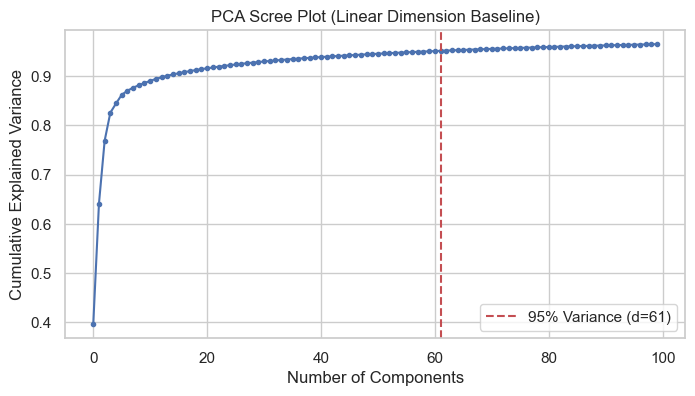

In [5]:
# --- 1. Linear Baseline (Scree Plot) ---
pca = PCA().fit(X)
explained_var = np.cumsum(pca.explained_variance_ratio_)
d_95 = np.argmax(explained_var >= 0.95) + 1

plt.figure(figsize=(8, 4))
plt.plot(explained_var[:100], marker='.')
plt.axvline(d_95, color='r', linestyle='--', label=f'95% Variance (d={d_95})')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot (Linear Dimension Baseline)')
plt.legend()
plt.grid(True)
plt.show()

In [6]:

# --- 2. Run Global Estimators ---
# All parameters are made explicit so that the numerical results are reproducible.

results = {}
params = {}
status = {}

# TwoNN on the raw fluctuating velocity snapshots.
# The discard fraction follows the usual TwoNN practice of removing the largest
# distance ratios, which are the most affected by finite-sample and boundary effects.
print("Running TwoNN on raw data...")
twonn, twonn_param_text = fit_twonn(X, discard_fraction=0.10)
results["TwoNN_raw"] = float(twonn.dimension_)
params["TwoNN_raw"] = twonn_param_text
status["TwoNN_raw"] = "computed"

# MiND_ML at a representative neighbourhood size.
k_mind = 20
D_mind = 100
print(f"Running MiND_ML (k={k_mind}, D={D_mind})...")
mind = MiND_ML(k=k_mind, D=D_mind)
mind.fit(X)
results["MiND_ML_k20"] = float(mind.dimension_)
params["MiND_ML_k20"] = f"k={k_mind}, D={D_mind}"
status["MiND_ML_k20"] = "computed"

# DANCo diagnostic with explicit search bound.
k_danco = 10
vt_danco = 0.99
ms_danco = 2000
D_danco = 100
print(f"Running DANCo diagnostic (k={k_danco}, PCA_var={vt_danco}, max_samples={ms_danco}, D_max={D_danco})...")
danco_info = danco_fast(
    X,
    max_samples=ms_danco,
    variance_threshold=vt_danco,
    k=k_danco,
    D_max=D_danco,
    random_state=42,
)
results["DANCo"] = danco_info["dimension"]
params["DANCo"] = f"k={k_danco}, PCA {vt_danco*100:.0f}% var, D={danco_info['D_search']}"
status["DANCo"] = danco_info["status"]

# Print results with parameters and diagnostic status.
print("\n--- Initial Estimates ---")
for name in results:
    print(f"{name:<15} ({params[name]}): {results[name]:.2f} [{status[name]}]")


Running TwoNN on raw data...
Running MiND_ML (k=20, D=100)...
Running DANCo diagnostic (k=10, PCA_var=0.99, max_samples=2000, D_max=100)...
  DANCo PCA reduction: 43200 -> 325 components (99% variance)
  DANCo searched dimensions: 1,...,100

--- Initial Estimates ---
TwoNN_raw       (discard_fraction=0.10): 42.00 [computed]
MiND_ML_k20     (k=20, D=100): 30.62 [computed]
DANCo           (k=10, PCA 99% var, D=100): 11.96 [interior_solution]



Running stability analysis (varying k)...


100%|██████████| 4/4 [05:39<00:00, 84.75s/it] 



PCA denoising: 61 components retain 95% of variance
TwoNN on PCA-denoised data: 21.66


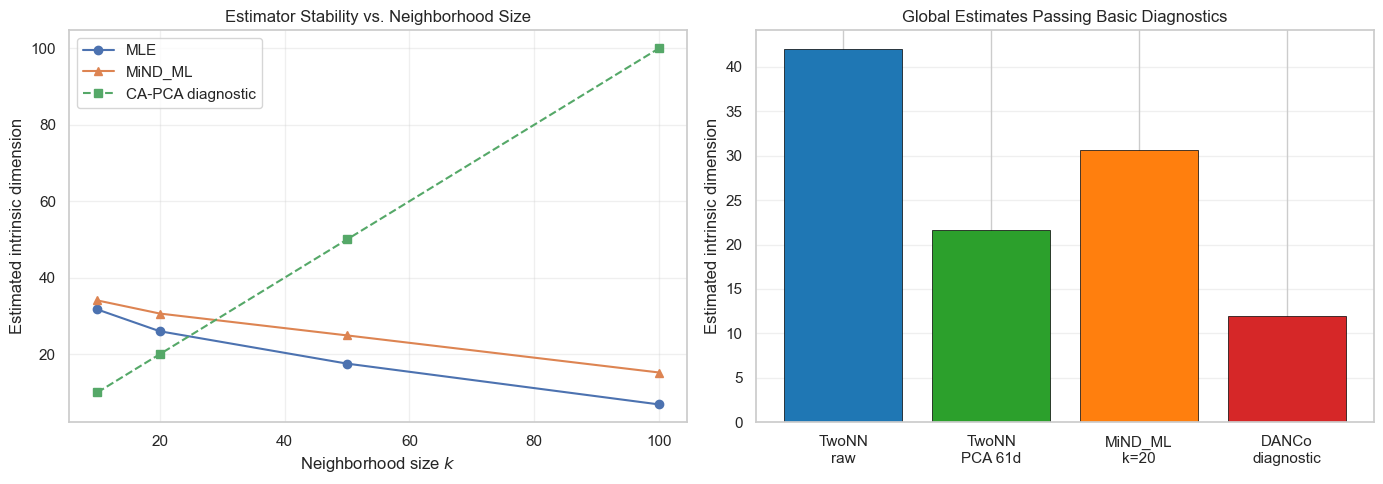


MLE estimates for k=[10, 20, 50, 100]: [31.69 26.   17.53  6.86]
MiND_ML estimates for k=[10, 20, 50, 100]: [34.06 30.62 24.91 15.21]
CA-PCA diagnostic estimates for k=[10, 20, 50, 100]: [ 10.  20.  50. 100.]
CA-PCA diagnostic k=10: status=boundary_failure, candidate_max=10, boundary_fraction=1.00
CA-PCA diagnostic k=20: status=boundary_failure, candidate_max=20, boundary_fraction=1.00
CA-PCA diagnostic k=50: status=boundary_failure, candidate_max=50, boundary_fraction=1.00
CA-PCA diagnostic k=100: status=boundary_failure, candidate_max=100, boundary_fraction=1.00
DANCo diagnostic: {'dimension': 11.955011990407673, 'n_pca_components': 325, 'D_search': 100, 'k': 10, 'status': 'interior_solution'}


In [7]:

# --- 3. Stability Analysis (Varying k) ---
# MLE is now called correctly: the neighbourhood size is passed to fit().

k_values = [10, 20, 50, 100]
mle_results = []
mind_results = []
capca_results = []
capca_status = []

print("\nRunning stability analysis (varying k)...")
for k in tqdm(k_values):
    # Levina--Bickel MLE. In scikit-dimension, n_neighbors must be passed here.
    mle = MLE().fit(X, n_neighbors=k)
    mle_results.append(float(mle.dimension_))

    # MiND_ML with the same explicit upper search dimension.
    mind_k = MiND_ML(k=k, D=D_mind).fit(X)
    mind_results.append(float(mind_k.dimension_))

    # CA-PCA diagnostic. This is not a primary estimator unless it avoids boundary saturation.
    id_capca, _, capca_info = ca_pca_estimator(
        X,
        k=k,
        D_max=min(D_mind, k),
        max_samples=1000,
        random_state=42,
    )
    capca_results.append(id_capca)
    capca_status.append(capca_info)

# --- 4. PCA-Denoised TwoNN ---
# PCA denoising removes low-energy measurement noise without feature-wise scaling.
pca_denoise = PCA(n_components=0.95)
X_denoised = pca_denoise.fit_transform(X)
n_components_95 = X_denoised.shape[1]
print(f"\nPCA denoising: {n_components_95} components retain 95% of variance")

twonn_denoised, twonn_denoised_param_text = fit_twonn(X_denoised, discard_fraction=0.10)
results["TwoNN_PCA95"] = float(twonn_denoised.dimension_)
params["TwoNN_PCA95"] = f"{twonn_denoised_param_text}, PCA 95% var = {n_components_95} components"
status["TwoNN_PCA95"] = "computed"
print(f"TwoNN on PCA-denoised data: {results['TwoNN_PCA95']:.2f}")

# --- 5. Plot Stability ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, mle_results, "o-", label="MLE")
axes[0].plot(k_values, mind_results, "^-", label="MiND_ML")
axes[0].plot(k_values, capca_results, "s--", label="CA-PCA diagnostic")
axes[0].set_xlabel("Neighborhood size $k$")
axes[0].set_ylabel("Estimated intrinsic dimension")
axes[0].set_title("Estimator Stability vs. Neighborhood Size")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Only use DANCo as a visual estimate if it did not hit the search boundary.
danco_plot_value = results["DANCo"] if status["DANCo"] == "interior_solution" else np.nan
all_names = ["TwoNN\nraw", f"TwoNN\nPCA {n_components_95}d", "MiND_ML\nk=20", "DANCo\ndiagnostic"]
all_vals = [results["TwoNN_raw"], results["TwoNN_PCA95"], results["MiND_ML_k20"], danco_plot_value]
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]
axes[1].bar(all_names, all_vals, color=colors, edgecolor="black", linewidth=0.5)
if status["DANCo"] != "interior_solution":
    axes[1].text(3, max([v for v in all_vals if np.isfinite(v)]) * 0.5, "boundary\nfailure", ha="center", va="center", fontsize=10)
axes[1].set_ylabel("Estimated intrinsic dimension")
axes[1].set_title("Global Estimates Passing Basic Diagnostics")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"\nMLE estimates for k={k_values}: {np.round(mle_results, 2)}")
print(f"MiND_ML estimates for k={k_values}: {np.round(mind_results, 2)}")
print(f"CA-PCA diagnostic estimates for k={k_values}: {np.round(capca_results, 2)}")
for info in capca_status:
    print(
        "CA-PCA diagnostic "
        f"k={info['k']}: status={info['status']}, "
        f"candidate_max={info['candidate_max']}, "
        f"boundary_fraction={info['boundary_fraction']:.2f}"
    )
print(f"DANCo diagnostic: {danco_info}")



## 7. Local Intrinsic Dimension

The manifold dimension may vary across snapshots. Local PCA provides a diagnostic local dimension for each snapshot by applying PCA inside a neighbourhood of each point.

The neighbourhood construction below explicitly requests one extra neighbour and removes the zero-distance self match. This avoids including the reference snapshot as one of its own neighbours.


Computing Local PCA with k=50 true neighbours...


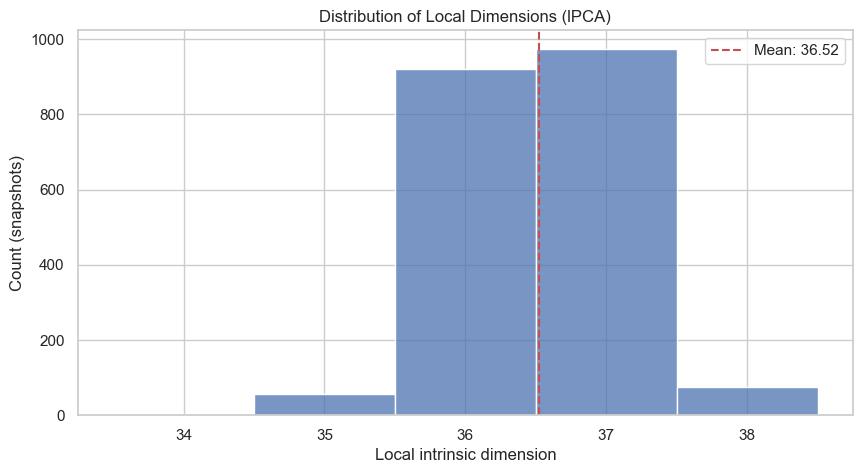

Local PCA mean dimension: 36.52
Local PCA median dimension: 37.00
Local PCA interquartile range: 36.00 -- 37.00


In [8]:

# Compute Local PCA.
k_local = 50
print(f"Computing Local PCA with k={k_local} true neighbours...")

# Precompute neighbours and remove self.
nn = NearestNeighbors(n_neighbors=k_local + 1).fit(X)
neighbors = nn.kneighbors(X, return_distance=False)[:, 1:]

# lPCA with an explained-variance rule inside each local neighbourhood.
lpca = lPCA(ver="ratio", alphaRatio=0.90)
local_ids = lpca.fit_transform_pw(X, precomputed_knn=neighbors)

plt.figure(figsize=(10, 5))
sns.histplot(local_ids, discrete=True, kde=False)
plt.axvline(np.mean(local_ids), color="r", linestyle="--", label=f"Mean: {np.mean(local_ids):.2f}")
plt.xlabel("Local intrinsic dimension")
plt.ylabel("Count (snapshots)")
plt.title("Distribution of Local Dimensions (lPCA)")
plt.legend()
plt.show()

print(f"Local PCA mean dimension: {np.mean(local_ids):.2f}")
print(f"Local PCA median dimension: {np.median(local_ids):.2f}")
print(f"Local PCA interquartile range: {np.percentile(local_ids, 25):.2f} -- {np.percentile(local_ids, 75):.2f}")


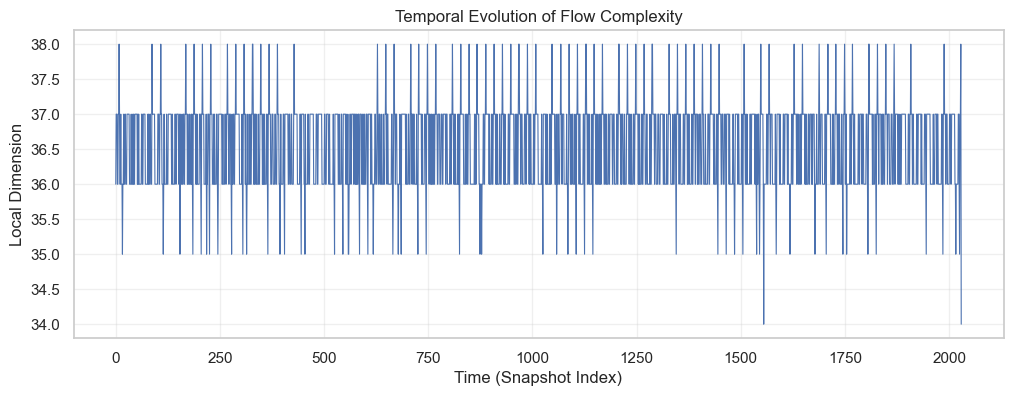

In [9]:
# Temporal Evolution of Complexity
plt.figure(figsize=(12, 4))
plt.plot(local_ids, lw=0.8)
plt.xlabel('Time (Snapshot Index)')
plt.ylabel('Local Dimension')
plt.title('Temporal Evolution of Flow Complexity')
plt.grid(True, alpha=0.3)
plt.show()

## Interpretation and Conclusions

The corrected intrinsic-dimension analysis was applied to RUN 2, corresponding to the forced jet at $St_{act}=0.30$. After spatial subsampling, each snapshot is represented in an ambient space of dimension $p=43\,200$, built from the unscaled fluctuating velocity components $(u,v)$. The estimates therefore describe the geometry of the physically measured fluctuation field, not a standardized or artificially reweighted feature space.

The PCA scree plot shows that 61 linear components retain 95% of the total variance. This value should not be interpreted as the intrinsic dimension, because PCA is a global linear method. It does, however, provide an important baseline: the energetic part of the velocity fluctuations occupies a much smaller subspace than the original $43\,200$-dimensional representation. The long variance tail indicates that low-energy turbulent or measurement-related directions remain present after the dominant coherent structures have been captured.

The nonlinear and neighbourhood-based estimators do not support a single scale-independent intrinsic dimension. TwoNN gives $d \approx 42.00$ on the raw data, whereas applying TwoNN after 95% PCA denoising gives $d \approx 21.66$. This difference is physically meaningful: the raw nearest-neighbour geometry is affected by small-amplitude high-dimensional fluctuations, while the PCA-denoised estimate reflects the geometry of the dominant coherent component of the flow.

The Levina--Bickel MLE and MiND_ML estimates decrease as the neighbourhood size $k$ increases. For $k=10$ and $k=20$, both methods give dimensions in the approximate range $26$-$34$, whereas larger neighbourhoods produce smaller estimates. This behaviour indicates that the estimated dimension depends on the spatial scale at which the data manifold is probed. Small neighbourhoods retain turbulent local variability, while larger neighbourhoods smooth over part of that variability and emphasize broader coherent organization. Therefore, the large-$k$ estimates should not be treated as definitive global dimensions.

DANCo returns an interior diagnostic estimate of $d \approx 11.96$ after PCA reduction retaining 99% of the variance. Since this result does not hit the imposed upper search boundary, it is valid as a diagnostic value. However, it is substantially lower than the raw TwoNN, MLE, MiND_ML, and local PCA results, so it should be interpreted as evidence of a strongly compressed coherent structure rather than as the sole final estimate.

The CA-PCA diagnostic fails its reliability check. For every tested neighbourhood size, the estimate equals the maximum admissible candidate dimension and the boundary fraction is 1.00. This means that the optimization is dominated by the imposed upper bound. Consequently, the CA-PCA values must be excluded from the thesis-level intrinsic-dimension estimate.

The local PCA analysis gives a mean local dimension of 36.52, a median of 37, and an interquartile range of 36-37. The temporal plot shows that the local dimension remains concentrated around this range throughout the acquisition, with only small integer fluctuations. This suggests that the local complexity of the forced jet is approximately stationary over time, rather than being caused by isolated high-complexity events.

Overall, the corrected analysis supports the manifold hypothesis for the PIV snapshots: the effective dimension is far below the ambient dimension $p=43\,200$. At the same time, the flow is not reducible to a very low-dimensional phase variable. A defensible conclusion is that the coherent, resolved geometry of RUN 2 has an effective intrinsic dimension of order $20$-$40$, with local neighbourhood structure concentrated near $36$-$37$. This range reflects the coexistence of phase-organized coherent motion and broadband turbulent fluctuations in the forced jet.